In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output

import random
import time

from Percolation import Percolation

In [89]:
class PercolationException(Exception):
    pass

In [90]:

class MonteCarlo:
    def __init__(self, n, m, timedelay=0.0001):
        self.n = n
        self.m = m
        
        if n<=0 or m<=0:
            raise ValueError("IllegalArgumentException - `n` or `m` is equal or less than 0")
        
        self.matrix = np.ones((n,m))
        self.tdelay = timedelay

        self.percolation = Percolation(n, m)

        #random
        self.indices = np.random.permutation(self.n * self.m)
        self.current = 0

    
    def __str__(self):
        return f"{self.matrix} \n with time delay plot: {self.tdelay} m/s"
    
    
    def StdRandom(self):
        
        idx = self.indices[self.current]
        self.current += 1

        rn = idx // self.m
        rm = idx % self.m

        return [rn, rm]
    
    def montecarlo(self):

        a, b = self.StdRandom()
        self.percolation.open(a,b)
        
        uf = self.percolation.uf
        
        df = self.percolation.uf.df
        firtrow = df[:self.m]
        lastrow = df[-self.m:]

        firstrow_root = []; lastrow_root = []

        for i in range(len(firtrow)):

            firstrow_root.append(self.percolation.uf.findroot(firtrow[i]))
            lastrow_root.append(self.percolation.uf.findroot(lastrow[i]))

        if set(firstrow_root).intersection(set(lastrow_root)):

            #Selecting the root of the match
            common_roots = set(firstrow_root).intersection(set(lastrow_root))
            match_root = list(common_roots)[0]

            #matrix of roots
            df_array = np.array(self.percolation.uf.df)
            roots = np.array([self.percolation.uf.findroot(i) for i in df_array])
            roots_matrix = roots.reshape(self.n, self.m)
            mask_path = (roots_matrix == match_root)
            visual = self.percolation.matrix.copy()

            visual = self.percolation.matrix.copy()
            visual[mask_path] = 2 # porcolation way

            return True, visual
            #raise self.PercolationException()

        else:
            return False, None

In [93]:
class PercolationStats:
    def __init__(self, n=15,m=15, T=7, TP=900):

        self.mc = MonteCarlo(n, m)
        self.n = n
        self.m = m
        self.T = T
        self.TP = TP
        self.data, self.swatcher, self.visual = self.run_simulation() #unique simulation

    def __str__(self):
        return f"Matrix final \n {self.visual}"
    
    def run_simulation(self):

        data = []; aux = 0; swatch=[]

        for i in range(self.T):

            aux=0
            self.mc = MonteCarlo(self.n, self.m) #reset montecarlo
            start_stopwatch = time.perf_counter()

            for j in range(self.TP):

                percolationtest, visual = self.mc.montecarlo()

                if percolationtest:
                    aux=j
                    break

            end_stopwatch = time.perf_counter()
            swatch.append(end_stopwatch - start_stopwatch)            
            
            if aux!=0:
                data.append(aux)
            else:
                data.append(self.TP)

        result = np.array(data)
        swatch = np.array(swatch)

        return result, swatch, visual
    
    
    def stats(self):

        counter = len(self.data[self.data!=self.TP])
        mean = np.mean(self.data)
        s2 = np.var(self.data, ddof=1)
        std_ = np.std(self.data, ddof=1)
        ic = np.array([
                        mean - (1.96 * np.sqrt(s2)) / np.sqrt(self.T),
                        mean + (1.96 * np.sqrt(s2)) / np.sqrt(self.T)
                    ])

        tcounter = len(self.swatcher[self.swatcher!=0])
        tmean = np.mean(self.swatcher)
        ts2 = np.var(self.swatcher, ddof=1)
        tic = np.array([
                        tmean - (1.96 * np.sqrt(ts2)) / np.sqrt(self.T),
                        tmean + (1.96 * np.sqrt(ts2)) / np.sqrt(self.T)
                        ])
        
        auxdf = {
        "counter": counter,
        "mean": mean,
        "variance": s2,
        "std":std_,
        "ic_low": ic[0],
        "ic_high": ic[1],
        "tmean": tmean,
        "tvariance": ts2,
        "tic_low": tic[0],
        "tic_high": tic[1]
        }

        df = pd.DataFrame([auxdf])
        return df

    def graph(self):

        statistics = self.stats().iloc[0]
        fig, axs = plt.subplots(2,2, figsize=(10, 10), constrained_layout=True)

        ############## Monte Carlo graph ##############

        cmap = ListedColormap([
                                    'white',        # 0 - bloqueado
                                    'black',        # 1 - aberto
                                    '#89CFF0'       # 2 - azul bebê
                                ])
        
        axs[0,0].imshow(self.visual,cmap=cmap,interpolation='nearest')
        axs[0,0].set_title(f"Monte Carlo Percolation \n dimension: {self.n}x{self.m}")

        ############## Histogram graph ##############
        axs[0,1].hist(self.data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
        axs[0,1].axvline(statistics['mean'], color="black", linestyle="-", label="Mean")
        axs[0,1].axvline(statistics['ic_low'], color="green", linestyle="--", alpha=.3)
        axs[0,1].axvline(statistics['ic_high'], color="green", linestyle="--", alpha=.3, label="96% confidence \n interval")
        axs[0,1].set_title("Gaussian Histogram")
        axs[0,1].set_xlabel("Percolation threshold")
        axs[0,1].set_ylabel("Density")

        # Normal Curve
        from scipy.stats import norm

        x = np.linspace(statistics['mean'] - 4*statistics['std'],
                        statistics['mean'] + 4*statistics['std'], 200)
        y = norm.pdf(x, statistics['mean'], statistics['std'])

        axs[0,1].plot(x, y, linewidth=2, label="Density estimate")

        axs[0,1].set_title("Percolation Distribution")
        axs[0,1].legend()

        ############## Runtime Convergence per Iteration ##############
        running_mean = np.cumsum(self.swatcher) / np.arange(1, len(self.swatcher)+1)
        axs[1,0].plot(self.swatcher, alpha=0.3, label="Iteration runtime")
        axs[1,0].plot(running_mean, label="Running mean")


        axs[1,0].set_xlabel("Iteration")
        axs[1,0].set_ylabel("Time (seconds)")
        axs[1,0].set_title("Runtime Convergence per Iteration")
        axs[1,0].legend()

        ############## Percolation Probality ##############
        #percolation_data = np.array(self.data[self.data!=self.TP])
        percolation_data = self.data
        threshold = percolation_data/(self.n * self.m)
        ps = np.linspace(0, 1, 50)
        probs = [(threshold <= p).mean() for p in ps]

        idx = np.argmin(np.abs(np.array(probs) - 0.5))
        p50 = ps[idx]

        axs[1,1].plot(ps, probs, label="Monte Carlo Estimate")
        axs[1,1].axvline(p50, color='black', alpha=.6, linestyle='--', label=f'p ≈ {p50:.3f}')
        axs[1,1].scatter(p50, probs[idx], color='red', alpha=.6)
        axs[1,1].set_title("Cumulative Distribution of Percolation Thresholds")
        axs[1,1].set_xlabel("site vacancy \n probability p")
        axs[1,1].set_ylabel("percolation \n probability")
        axs[1,1].legend()




    def summary(self):

        statistics = self.stats()
        statistics = statistics.iloc[0]

        return f""" \n 
                ╔══════════════════════════════════════════════════════════╗
                ║                   PERCOLATION Statistics                 ║
                ╚══════════════════════════════════════════════════════════╝
                📊 Percolation
                   ├─ Count      : {statistics['counter']:.0f}
                   ├─ Mean       : {statistics['mean']:.3f}
                   ├─ Variance   : {statistics['variance']:.3f}
                   └─ CI (96%)   : [{statistics['ic_low']:.3f}, {statistics['ic_high']:.3f}]
                \n
                ⏱️ Runtime
                   ├─ Mean       : {statistics['tmean']:.2e} s
                   ├─ Variance   : {statistics['tvariance']:.2e}
                   └─ CI (96%)   : [{statistics['tic_low']:.3f}, {statistics['tic_high']:.3f}]
                \n
                ════════════════════════════════════════════════════════

        """
    
    def PercolationStatistics(self):

        print(self.summary())
        self.graph()

 
 
                ╔══════════════════════════════════════════════════════════╗
                ║                   PERCOLATION Statistics                 ║
                ╚══════════════════════════════════════════════════════════╝
                📊 Percolation
                   ├─ Count      : 100
                   ├─ Mean       : 5926.680
                   ├─ Variance   : 24309.977
                   └─ CI (96%)   : [5896.120, 5957.240]
                

                ⏱️ Runtime
                   ├─ Mean       : 3.52e-01 s
                   ├─ Variance   : 2.08e-04
                   └─ CI (96%)   : [0.349, 0.355]
                

                ════════════════════════════════════════════════════════

        


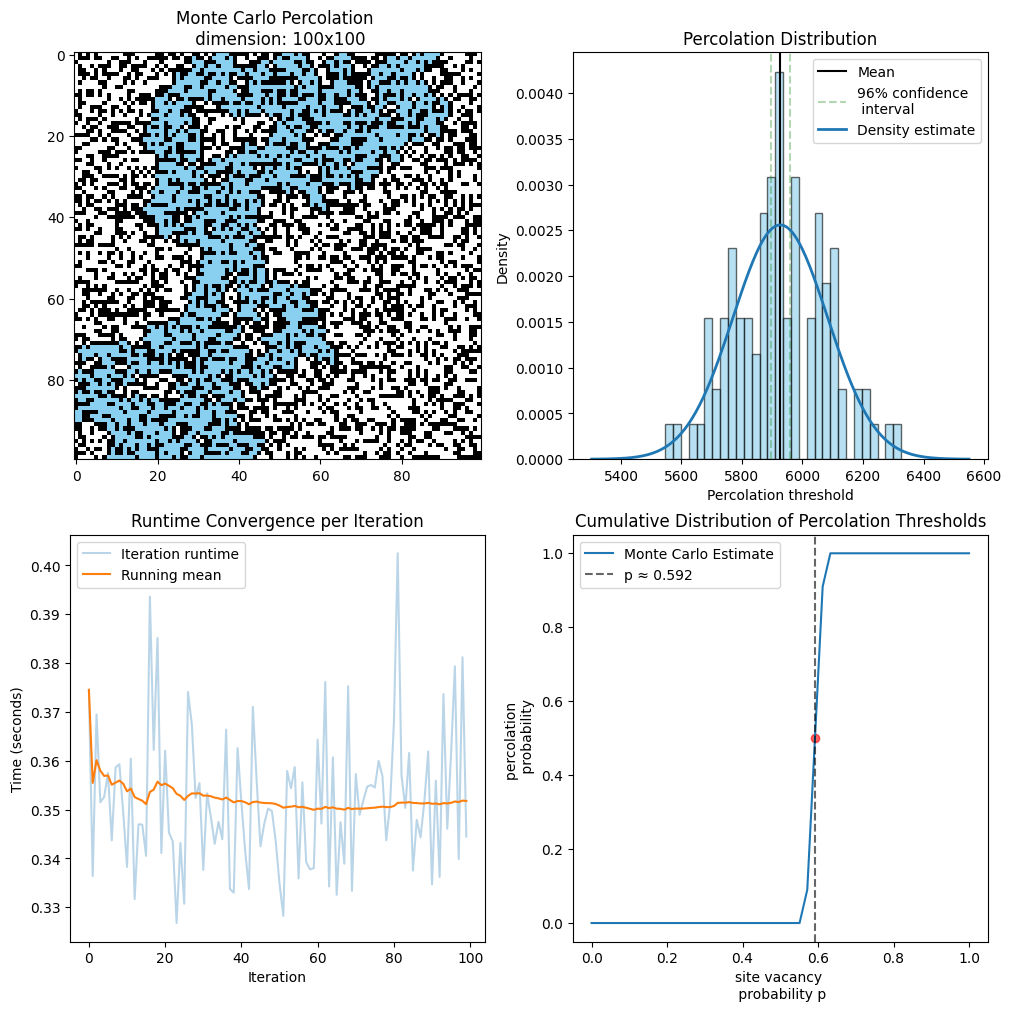

In [94]:
sts = PercolationStats(n=100,m=100, T=100, TP=1000000)
sts.PercolationStatistics()